In [ ]:
# Install dependencies
#%pip install chembl_webresource_client rdkit torch

In [2]:
# Load Libraries
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit.DataStructs import BulkTanimotoSimilarity
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from chembl_webresource_client.new_client import new_client


In [3]:
# Check Mac GPU availability
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:    ", torch.backends.mps.is_built())
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


MPS available: True
MPS built:     True
Using device: mps


In [4]:
# Step 1 — Load ZINC250K candidates
url        = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
df         = pd.read_csv(url)
candidates = df["smiles"].tolist()[:100000]
print(f"Candidates loaded: {len(candidates)}")



# Step 2 — Load ChEMBL HMGCR reference (API with local fallback)
LOCAL_PATH = "/Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks/molgpt/datasets/statin.csv"

try:
    from chembl_webresource_client.new_client import new_client
    activity      = new_client.activity
    acts          = activity.filter(
                        target_chembl_id="CHEMBL1781",
                        standard_type="IC50"
                    ).only("canonical_smiles")
    chembl_smiles = [a["canonical_smiles"] for a in acts if a["canonical_smiles"]]
    print(f"ChEMBL API: {len(chembl_smiles)} compounds loaded")

except Exception as e:
    print(f"ChEMBL API unavailable ({e.__class__.__name__}) — loading from local file")
    df_local      = pd.read_csv(LOCAL_PATH)
    chembl_smiles = df_local["smiles"].tolist()
    print(f"Local fallback: {len(chembl_smiles)} compounds loaded")

Candidates loaded: 100000
ChEMBL API: 735 compounds loaded


In [5]:
# Step 3 — Fingerprint generator (created once, reused for all molecules)
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def encode(smi):
    """Parse SMILES and return 2048-bit Morgan fingerprint. Returns None if invalid."""
    try:
        mol = Chem.MolFromSmiles(str(smi).strip())
        if mol is None: return None
        return gen.GetFingerprint(mol)
    except:
        return None

# Step 4 — Encode reference fingerprints (CPU, ThreadPoolExecutor)
print("Encoding ChEMBL reference...")
with ThreadPoolExecutor() as ex:
    ref_fps_raw = list(ex.map(encode, chembl_smiles))
ref_fps = [fp for fp in ref_fps_raw if fp is not None]
print(f"Valid reference fps: {len(ref_fps)}")

# Move reference fingerprints to Mac GPU (MPS) as a tensor
# Shape: [n_ref, 2048] — all 735 reference fingerprints in one matrix
ref_tensor = torch.tensor(
    [list(fp) for fp in ref_fps],
    dtype=torch.float32
).to(device)
print(f"Reference loaded on GPU: {ref_tensor.shape}")

# Step 5 — Encode all ZINC candidates (CPU, ThreadPoolExecutor)
print("Encoding ZINC candidates...")
with ThreadPoolExecutor() as ex:
    cand_fps_raw = list(ex.map(encode, candidates))

candidate_fps = [
    (smi, fp)
    for smi, fp in zip(candidates, cand_fps_raw)
    if fp is not None
]
print(f"Valid candidates: {len(candidate_fps)}")

# Step 6 — Score on Mac GPU in batches (vectorised Tanimoto)
# Formula: Tanimoto = intersection / union
#          intersection = dot product of binary vectors
#          union = sum_A + sum_B - intersection
print("Scoring ZINC on Mac GPU...")
BATCH   = 1000
results = []
smiles_list = [smi for smi, _ in candidate_fps]
fps_list    = [fp  for _,  fp in candidate_fps]

for i in range(0, len(fps_list), BATCH):
    batch_fps  = fps_list[i:i+BATCH]
    batch_smi  = smiles_list[i:i+BATCH]

    query      = torch.tensor([list(fp) for fp in batch_fps],
                               dtype=torch.float32).to(device)
    inter      = torch.mm(query, ref_tensor.T)
    query_sum  = query.sum(dim=1, keepdim=True)
    ref_sum    = ref_tensor.sum(dim=1, keepdim=True)
    union      = query_sum + ref_sum.T - inter
    tanimoto   = (inter / union).max(dim=1).values
    scores     = tanimoto.cpu().numpy()

    for smi, score in zip(batch_smi, scores):
        results.append({"smiles": smi, "tanimoto": float(score)})

    if (i // BATCH) % 10 == 0:
        print(f"  {min(i+BATCH, len(fps_list))}/{len(fps_list)}")

df_results = pd.DataFrame(results)
print(f"\nScored: {len(df_results)}")
print(df_results["tanimoto"].describe())


Encoding ChEMBL reference...
Valid reference fps: 735
Reference loaded on GPU: torch.Size([735, 2048])
Encoding ZINC candidates...
Valid candidates: 100000
Scoring ZINC on Mac GPU...
  1000/100000
  11000/100000
  21000/100000
  31000/100000
  41000/100000
  51000/100000
  61000/100000
  71000/100000
  81000/100000
  91000/100000

Scored: 100000
count    100000.000000
mean          0.224507
std           0.055829
min           0.064935
25%           0.187500
50%           0.217949
75%           0.253731
max           0.689655
Name: tanimoto, dtype: float64


In [6]:
# Step 7 — Load MolGPT candidates (10,000 generation run)
print("Loading MolGPT...")
molgpt_path = "/Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks/molgpt/generated_statins_10k.csv"
df_gen      = pd.read_csv(molgpt_path)
gen_smiles  = df_gen["smiles"].tolist()
print(f"MolGPT candidates loaded: {len(gen_smiles)}")

# Step 8 — Score MolGPT candidates on GPU (filter trivial < 10 atoms)
print("Scoring MolGPT on Mac GPU...")
molgpt_results = []
for smi in gen_smiles:
    try:
        mol = Chem.MolFromSmiles(str(smi).strip())
        if mol is None or mol.GetNumAtoms() < 10: continue
        fp = encode(smi)
        if fp is None: continue
        query     = torch.tensor([list(fp)], dtype=torch.float32).to(device)
        inter     = torch.mm(query, ref_tensor.T)
        union     = query.sum() + ref_tensor.sum(dim=1) - inter
        tanimoto  = (inter / union).max().item()
        molgpt_results.append({"smiles": smi, "tanimoto": tanimoto})
    except:
        continue

df_molgpt = pd.DataFrame(molgpt_results)
print(f"MolGPT valid non-trivial: {len(df_molgpt)}")
print(df_molgpt["tanimoto"].describe())


Loading MolGPT...
MolGPT candidates loaded: 188
Scoring MolGPT on Mac GPU...
MolGPT valid non-trivial: 125
count    125.000000
mean       0.659490
std        0.276191
min        0.122222
25%        0.462500
50%        0.666667
75%        1.000000
max        1.000000
Name: tanimoto, dtype: float64


In [7]:
# Step 9 — Filter hits by Tanimoto threshold
zinc_hits   = df_results[df_results["tanimoto"] > 0.40].copy()
molgpt_hits = df_molgpt[df_molgpt["tanimoto"]   > 0.40].copy()
print(f"ZINC hits >0.40:   {len(zinc_hits)}")
print(f"MolGPT hits >0.40: {len(molgpt_hits)}")
print(f"ZINC hits >0.60:   {(df_results['tanimoto'] > 0.60).sum()}")
print(f"MolGPT hits >0.60: {(df_molgpt['tanimoto']  > 0.60).sum()}")


ZINC hits >0.40:   973
MolGPT hits >0.40: 101
ZINC hits >0.60:   12
MolGPT hits >0.60: 70


In [8]:
# Step 10 — Compute descriptors on hits only (not all 100k candidates)
def get_descriptors(smi):
    mol = Chem.MolFromSmiles(str(smi).strip())
    if mol is None: return {}
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {"mw": round(mw,2), "logp": round(logp,2),
            "hbd": hbd, "hba": hba, "qed": round(qed,3), "violations": viol}

# PAINS filter — build catalog once
pains_params = FilterCatalogParams()
pains_params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(pains_params)

def has_pains(smi):
    mol = Chem.MolFromSmiles(str(smi).strip())
    if mol is None: return True
    return pains_catalog.GetFirstMatch(mol) is not None

for df in [zinc_hits, molgpt_hits]:
    desc             = df["smiles"].apply(get_descriptors).apply(pd.Series)
    df[desc.columns] = desc.values
    df["pains"]      = df["smiles"].apply(has_pains)

# Summary
def summary(name, df_all, df_hits):
    clean = ((df_hits["violations"] == 0) & (~df_hits["pains"])).sum()
    print(f"\n{name}")
    print(f"  Total scored:    {len(df_all)}")
    print(f"  Hits >0.40:      {len(df_hits)}")
    print(f"  Hits >0.60:      {(df_all['tanimoto'] > 0.60).sum()}")
    print(f"  Lipinski pass:   {(df_hits['violations'] == 0).sum()}")
    print(f"  PAINS clean:     {(~df_hits['pains']).sum()}")
    print(f"  Clean total:     {clean}")
    print(f"  Mean tanimoto:   {df_all['tanimoto'].mean():.3f}")
    if len(df_hits) > 0:
        print(f"  Mean QED:        {df_hits['qed'].mean():.3f}")

summary("ZINC250K",   df_results, zinc_hits)
summary("MolGPT",     df_molgpt,  molgpt_hits)



ZINC250K
  Total scored:    100000
  Hits >0.40:      973
  Hits >0.60:      12
  Lipinski pass:   936
  PAINS clean:     944
  Clean total:     908
  Mean tanimoto:   0.225
  Mean QED:        0.729

MolGPT
  Total scored:    125
  Hits >0.40:      101
  Hits >0.60:      70
  Lipinski pass:   101
  PAINS clean:     99
  Clean total:     99
  Mean tanimoto:   0.659
  Mean QED:        0.557


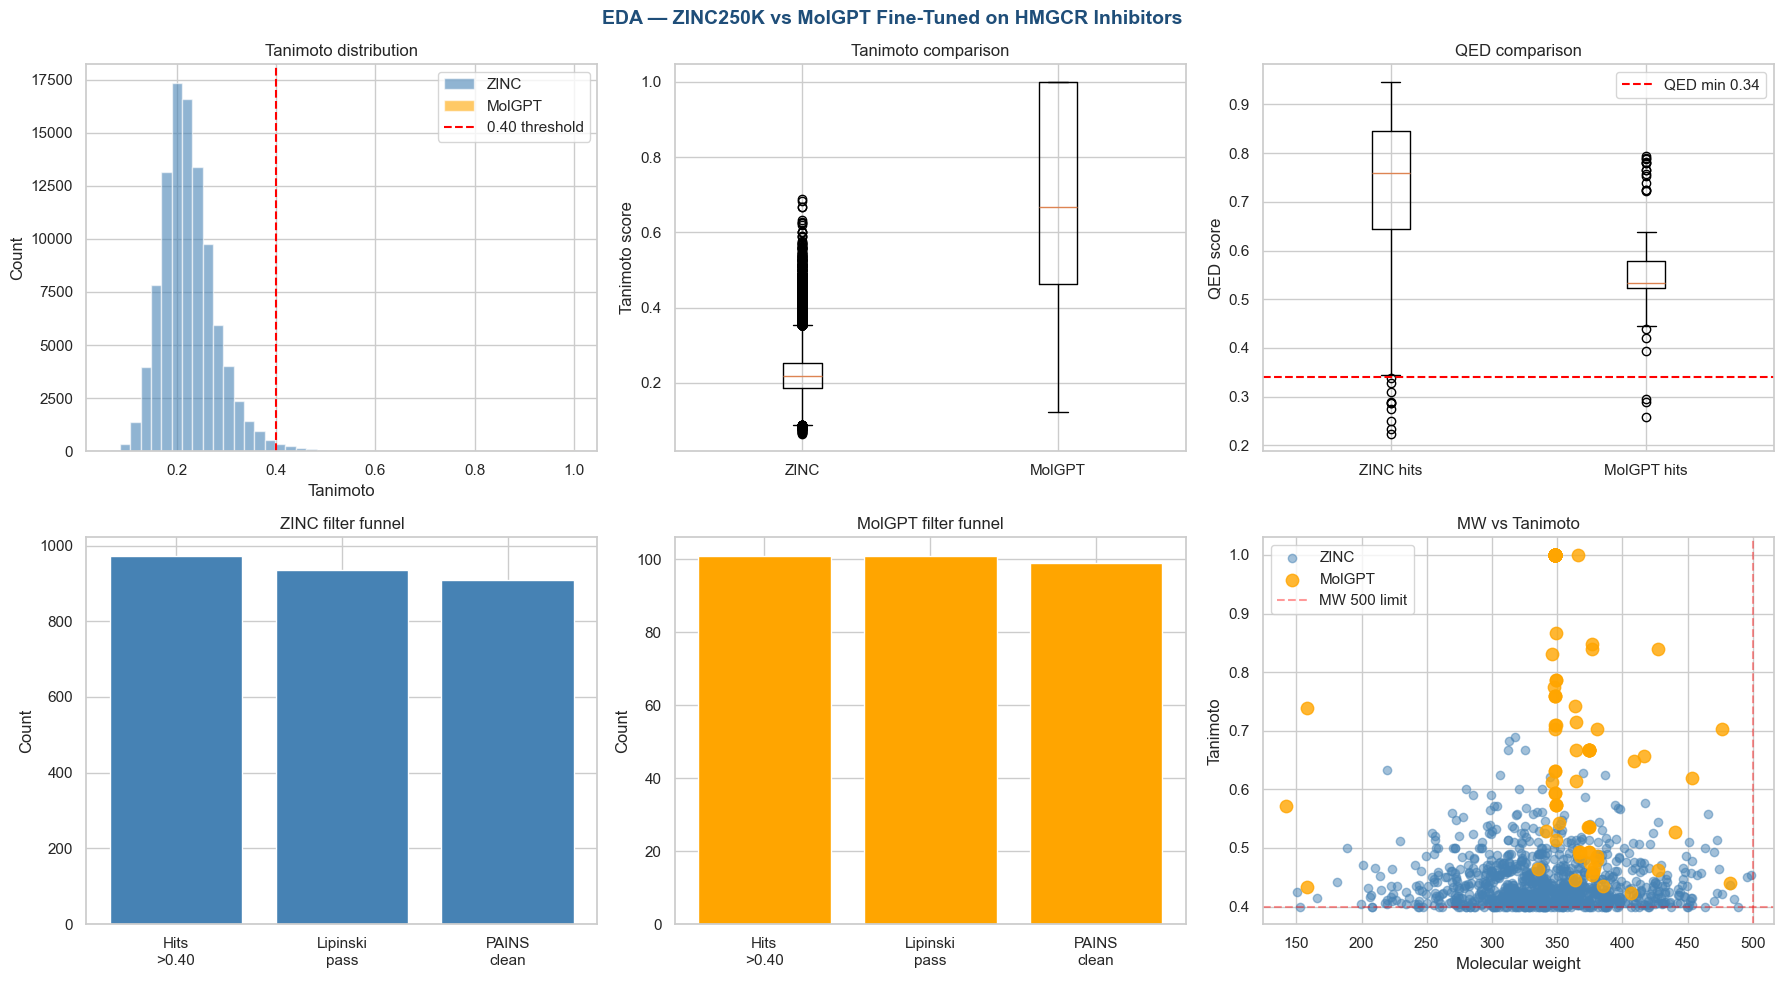

In [9]:
# Step 11 — Visualisations
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — ZINC250K vs MolGPT Fine-Tuned on HMGCR Inhibitors",
             fontsize=14, fontweight="bold", color="#1F4E79")

# Plot 1 — Tanimoto histogram
axes[0,0].hist(df_results["tanimoto"],  bins=30, alpha=0.6, label="ZINC",   color="steelblue")
axes[0,0].hist(df_molgpt["tanimoto"],   bins=15, alpha=0.6, label="MolGPT", color="orange")
axes[0,0].axvline(0.40, color="red", linestyle="--", label="0.40 threshold")
axes[0,0].set(title="Tanimoto distribution", xlabel="Tanimoto", ylabel="Count")
axes[0,0].legend()

# Plot 2 — Tanimoto boxplot
axes[0,1].boxplot(
    [df_results["tanimoto"].tolist(), df_molgpt["tanimoto"].tolist()],
    tick_labels=["ZINC", "MolGPT"]
)
axes[0,1].set(title="Tanimoto comparison", ylabel="Tanimoto score")

# Plot 3 — QED comparison on hits
if len(zinc_hits) > 0 and len(molgpt_hits) > 0:
    axes[0,2].boxplot(
        [zinc_hits["qed"].tolist(), molgpt_hits["qed"].tolist()],
        tick_labels=["ZINC hits", "MolGPT hits"]
    )
axes[0,2].axhline(0.34, color="red", linestyle="--", label="QED min 0.34")
axes[0,2].set(title="QED comparison", ylabel="QED score")
axes[0,2].legend()

# Plot 4 — ZINC filter funnel
zinc_clean = ((zinc_hits["violations"] == 0) & (~zinc_hits["pains"])).sum()
axes[1,0].bar(
    ["Hits\n>0.40", "Lipinski\npass", "PAINS\nclean"],
    [len(zinc_hits), (zinc_hits["violations"]==0).sum(), zinc_clean],
    color="steelblue"
)
axes[1,0].set(title="ZINC filter funnel", ylabel="Count")

# Plot 5 — MolGPT filter funnel
molgpt_clean = ((molgpt_hits["violations"] == 0) & (~molgpt_hits["pains"])).sum()
axes[1,1].bar(
    ["Hits\n>0.40", "Lipinski\npass", "PAINS\nclean"],
    [len(molgpt_hits), (molgpt_hits["violations"]==0).sum(), molgpt_clean],
    color="orange"
)
axes[1,1].set(title="MolGPT filter funnel", ylabel="Count")

# Plot 6 — MW vs Tanimoto scatter
if len(zinc_hits) > 0:
    axes[1,2].scatter(zinc_hits["mw"],   zinc_hits["tanimoto"],
                      alpha=0.5, label="ZINC",   color="steelblue")
if len(molgpt_hits) > 0:
    axes[1,2].scatter(molgpt_hits["mw"], molgpt_hits["tanimoto"],
                      alpha=0.8, label="MolGPT", color="orange", s=80)
axes[1,2].axhline(0.40, color="red", linestyle="--", alpha=0.4)
axes[1,2].axvline(500,  color="red", linestyle="--", alpha=0.4, label="MW 500 limit")
axes[1,2].set(title="MW vs Tanimoto", xlabel="Molecular weight", ylabel="Tanimoto")
axes[1,2].legend()

plt.tight_layout()
plt.savefig("eda_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


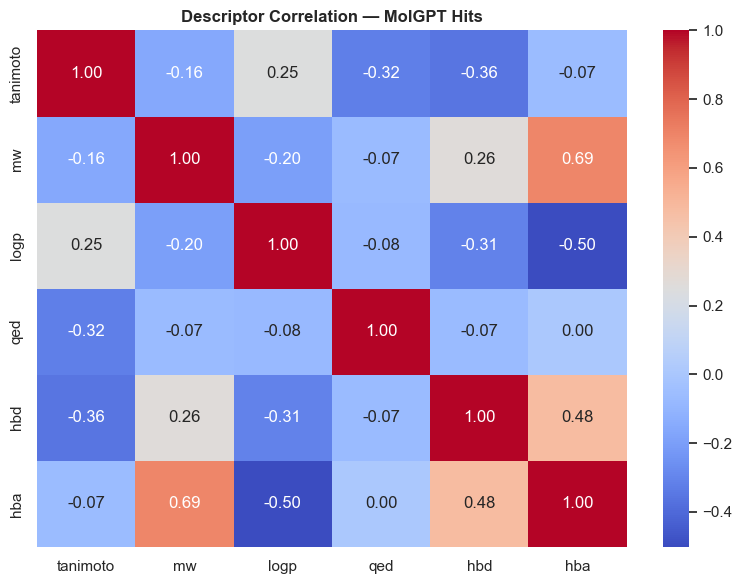

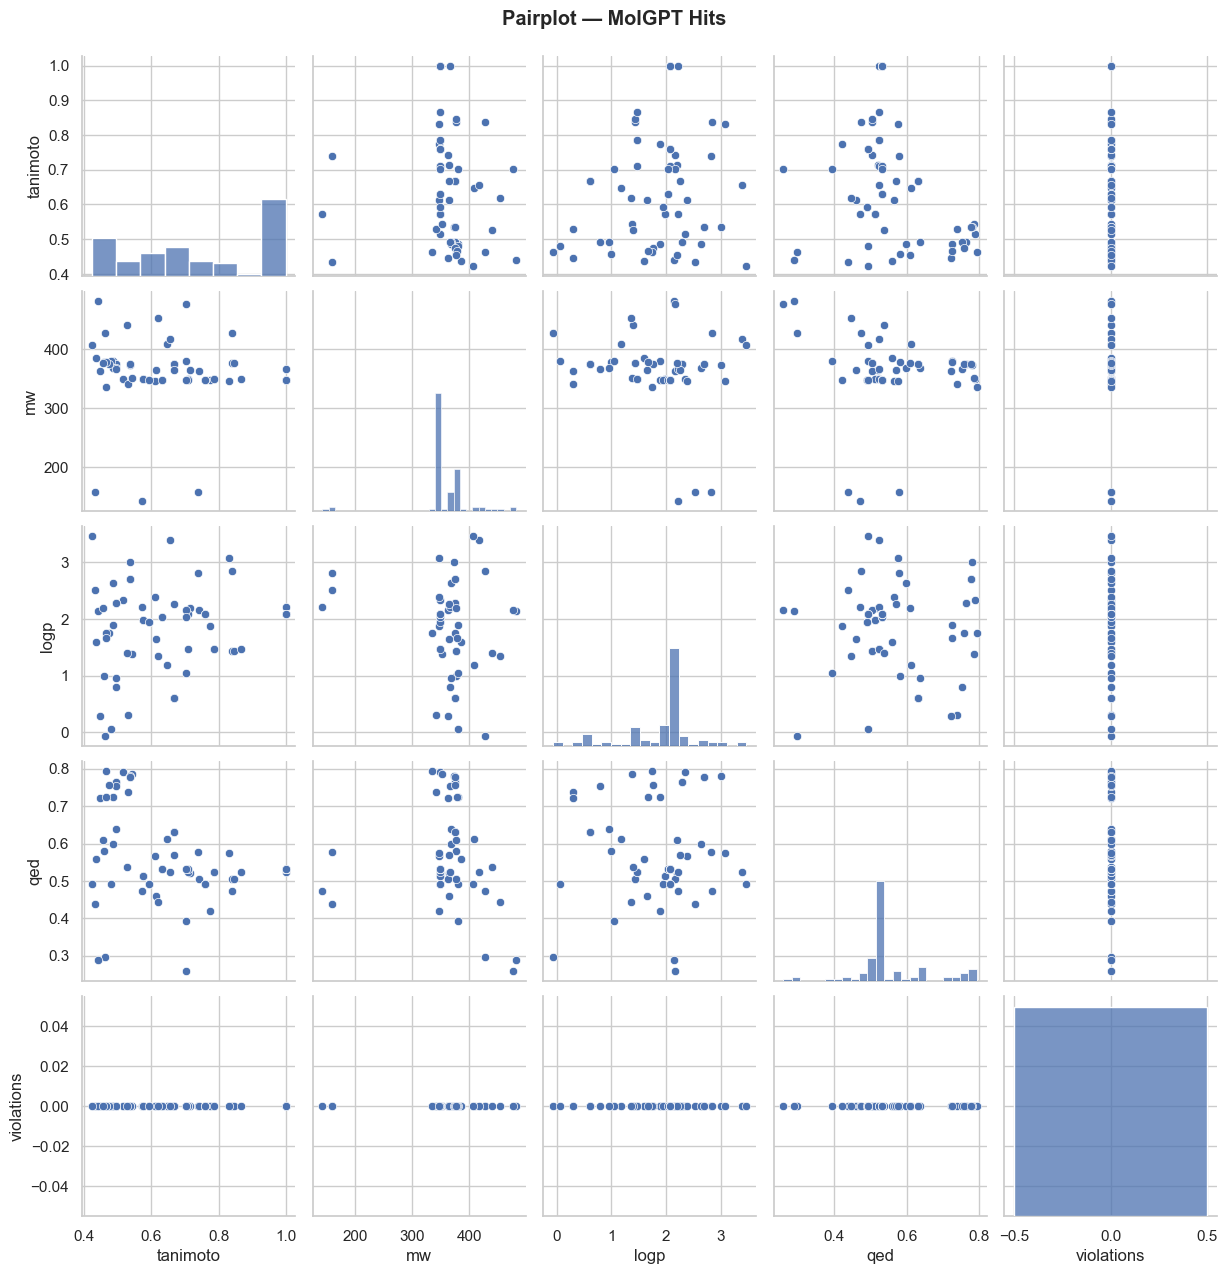

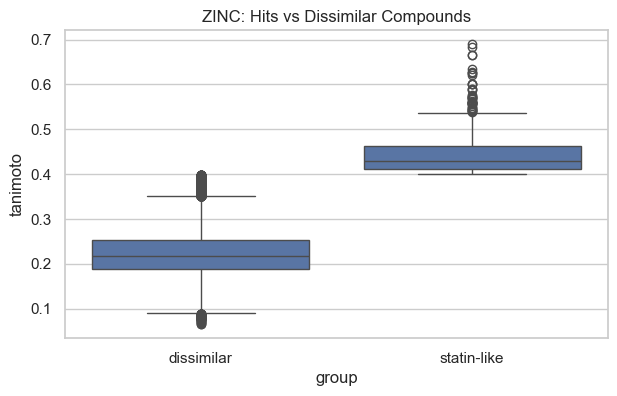

In [10]:
# Plot 7 — Correlation heatmap (MolGPT hits)
if len(molgpt_hits) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        molgpt_hits[["tanimoto","mw","logp","qed","hbd","hba"]].corr(),
        annot=True, cmap="coolwarm", fmt=".2f"
    )
    plt.title("Descriptor Correlation — MolGPT Hits", fontweight="bold")
    plt.tight_layout()
    plt.show()

# Plot 8 — Pairplot (MolGPT hits)
if len(molgpt_hits) > 1:
    sns.pairplot(
        molgpt_hits[["tanimoto","mw","logp","qed","violations"]],
        diag_kind="hist"
    )
    plt.suptitle("Pairplot — MolGPT Hits", y=1.02, fontweight="bold")
    plt.show()

# Group plot — hits vs dissimilar
df_results["group"] = df_results["tanimoto"].apply(
    lambda x: "statin-like" if x > 0.40 else "dissimilar"
)
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_results, x="group", y="tanimoto")
plt.title("ZINC: Hits vs Dissimilar Compounds")
plt.show()


In [11]:
%pip install cairosvg
#%pip install cairosvg

Note: you may need to restart the kernel to use updated packages.


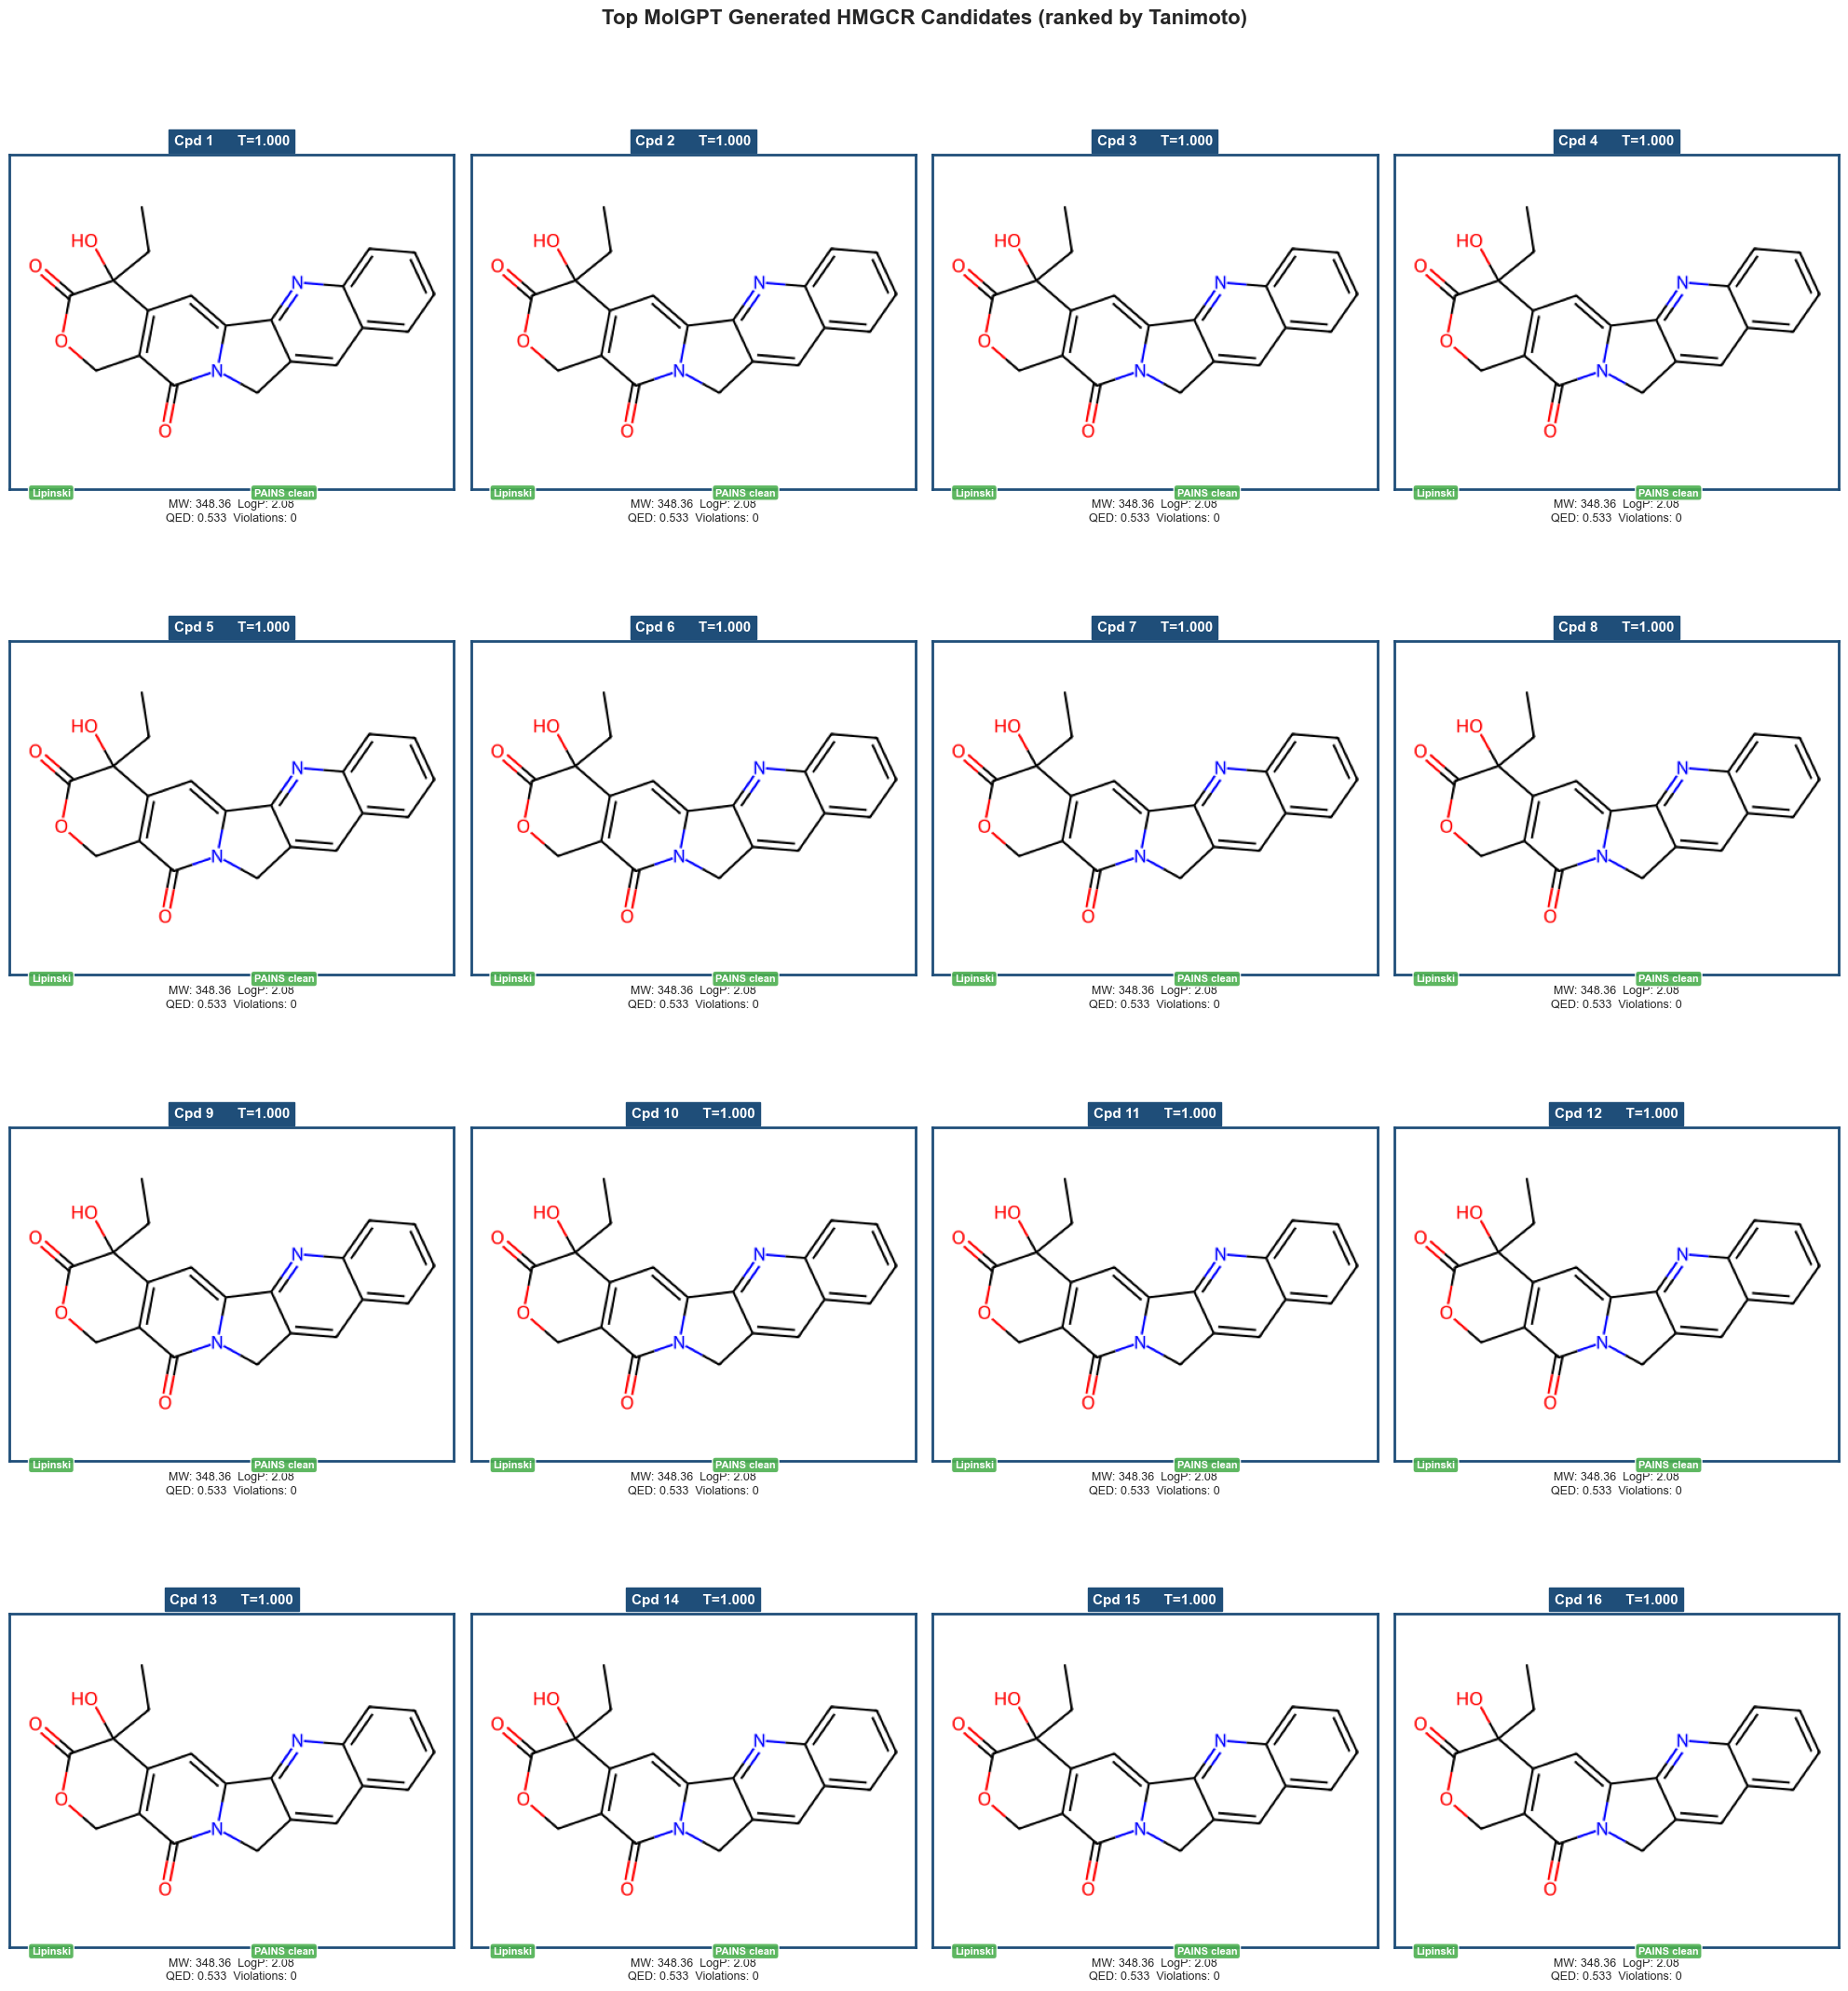

Saved eda_molgpt_structures.png with 16 compounds


In [13]:
# Visualize the top MolGPT generated HMGCR candidates
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

# Select top candidates ranked by Tanimoto (up to 16)
top = molgpt_hits.sort_values("tanimoto", ascending=False).head(16).reset_index(drop=True)
n = len(top)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5.5 * nrows))
fig.suptitle("Top MolGPT Generated HMGCR Candidates (ranked by Tanimoto)",
             fontsize=16, fontweight="bold", y=1.0)

if nrows == 1:
    axes = axes.reshape(1, -1)

for idx in range(nrows * ncols):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]
    ax.set_xticks([])
    ax.set_yticks([])

    if idx >= n:
        ax.axis("off")
        continue

    entry = top.iloc[idx]
    smi = entry["smiles"]
    mol = Chem.MolFromSmiles(str(smi).strip())

    # Draw molecule via RDKit's PIL-based renderer (no cairo dependency)
    if mol is not None:
        img = Draw.MolToImage(mol, size=(400, 300))
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "Invalid SMILES", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="red")

    # Header: compound number + Tanimoto score
    header_color = "#1F4E79"
    ax.set_title(f"Cpd {idx+1}      T={entry['tanimoto']:.3f}",
                 fontsize=11, fontweight="bold", color="white",
                 backgroundcolor=header_color, pad=8)

    # Footer: properties
    props = (f"MW: {entry['mw']}  LogP: {entry['logp']}\n"
             f"QED: {entry['qed']}  Violations: {int(entry['violations'])}")
    ax.set_xlabel(props, fontsize=9, labelpad=8)

    # Lipinski / PAINS badges
    lip_color = "#4CAF50" if entry["violations"] == 0 else "#F44336"
    pains_color = "#4CAF50" if not entry["pains"] else "#F44336"
    lip_text = "Lipinski" if entry["violations"] == 0 else f"Lipinski ({int(entry['violations'])} viol)"
    pains_text = "PAINS clean" if not entry["pains"] else "PAINS alert"

    ax.annotate(lip_text, xy=(0.05, -0.02), xycoords="axes fraction",
                fontsize=8, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=lip_color, alpha=0.9))
    ax.annotate(pains_text, xy=(0.55, -0.02), xycoords="axes fraction",
                fontsize=8, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=pains_color, alpha=0.9))

    # Border
    for spine in ax.spines.values():
        spine.set_edgecolor(header_color)
        spine.set_linewidth(2)

plt.tight_layout()
plt.savefig("eda_molgpt_structures.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved eda_molgpt_structures.png with {n} compounds")

In [ ]:
# =============================================================
# REFERENCES
# =============================================================
# [1] Bagal S et al. MolGPT. J Chem Inf Model. 2022.
#     https://arxiv.org/abs/2004.01507
#     Used for: the generative model that produced all AI-generated
#     HMGCR candidates evaluated in this EDA.
#
# [2] Gaulton A et al. ChEMBL. Nucleic Acids Res. 2012.
#     https://doi.org/10.1093/nar/gkr777
#     Used for: the 735 HMGCR inhibitor SMILES used as the gold
#     standard reference set, and the 665 MolGPT training compounds.
#
# [3] Irwin JJ et al. ZINC. J Chem Inf Model. 2012.
#     https://doi.org/10.1021/ci3001277
#     Used for: the 100,000 ZINC250K compounds used as the
#     baseline comparison library.
#
# [4] Rogers D, Hahn M. ECFP Fingerprints. J Chem Inf Model. 2010.
#     https://doi.org/10.1021/ci100050t
#     Used for: Morgan/ECFP4 fingerprinting (radius=2, 2048-bit)
#     used to compute every Tanimoto score in this EDA.
#
# [5] Bickerton GR et al. QED. Nat Chem. 2012.
#     https://doi.org/10.1038/nchem.1243
#     Used for: QED drug-likeness metric and the 0.34 minimum
#     threshold applied in the filter funnel.
#
# [6] Baell JB, Holloway GA. PAINS. J Med Chem. 2010.
#     https://doi.org/10.1021/jm901137j
#     Used for: PAINS substructure filter — 480 problematic
#     patterns that disqualify compounds from the clean candidate set.
#
# [7] Landrum G. RDKit: Open-source cheminformatics. rdkit.org. 2006.
#     Used for: every cheminformatics operation — SMILES parsing,
#     fingerprint generation, Tanimoto scoring, QED, PAINS, 2D drawing.
#
# [8] BulkTanimotoSimilarity C++ API. RDKit docs.
#     https://www.rdkit.org/docs/source/rdkit.DataStructs.cDataStructs.html
#     Used for: fast C++ Tanimoto computation against all 735
#     reference fingerprints in a single call (10-20x faster than looping).
# =============================================================
